In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs("plots", exist_ok=True)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [4]:
print("\n=== Dataset Shape ===")
print(df.shape)


=== Dataset Shape ===
(1470, 35)


In [5]:
print("\n=== Column Names ===")
print(df.columns.tolist())


=== Column Names ===
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64


In [7]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRo

In [8]:
print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())


=== Duplicate Rows ===
0


In [9]:
print("\n=== Attrition Count ===")
print(df["Attrition"].value_counts())


=== Attrition Count ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64


Visualization 1: Attrition Rate by Overtime

In [10]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

In [11]:
print("\n=== Attrition Rate by Overtime ===")
print(overtime_attrition)


=== Attrition Rate by Overtime ===
OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64


In [12]:
plt.figure(figsize=(7, 5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Axes: xlabel='OverTime'>

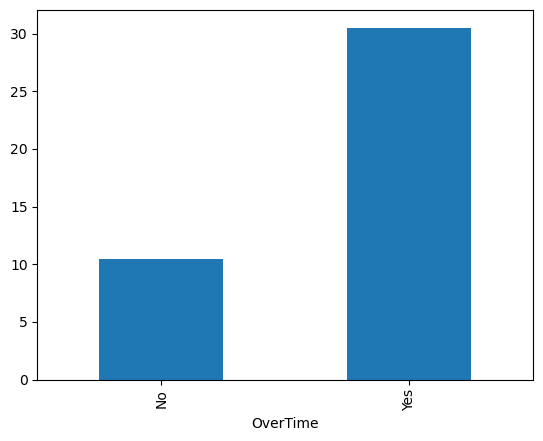

In [13]:
overtime_attrition.plot(kind="bar")

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

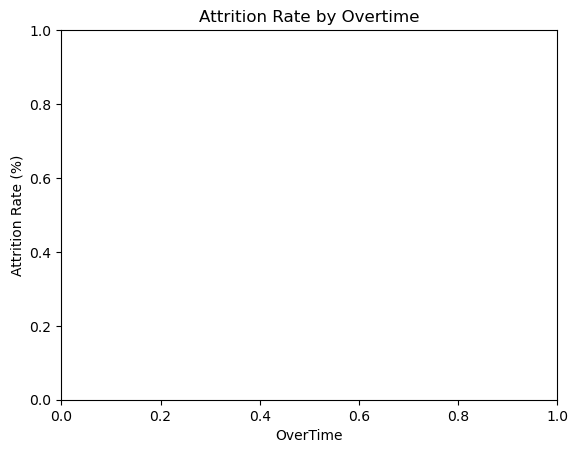

In [14]:
plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

In [15]:
plt.tight_layout()
plt.savefig("plots/attrition_overtime.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/monthly_income_attrition.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/attrition_job_satisfaction.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/attrition_job_role.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/attrition_age.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/attrition_job_involvement.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

Visualization 2: Monthly Income vs Attrition

In [16]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Axes: title={'center': 'MonthlyIncome'}, xlabel='Attrition'>

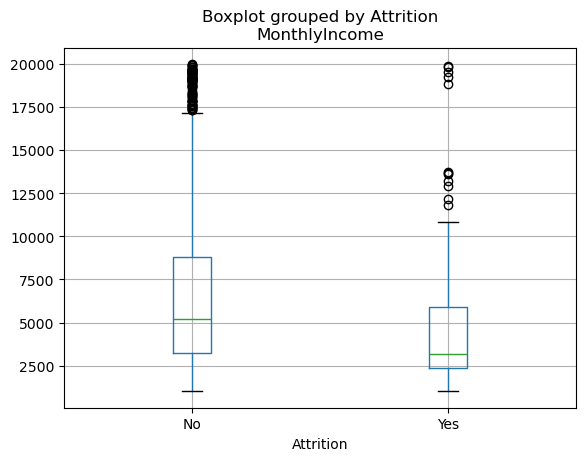

In [17]:
df.boxplot(
    column="MonthlyIncome",
    by="Attrition"
)

Text(0, 0.5, 'Monthly Income')

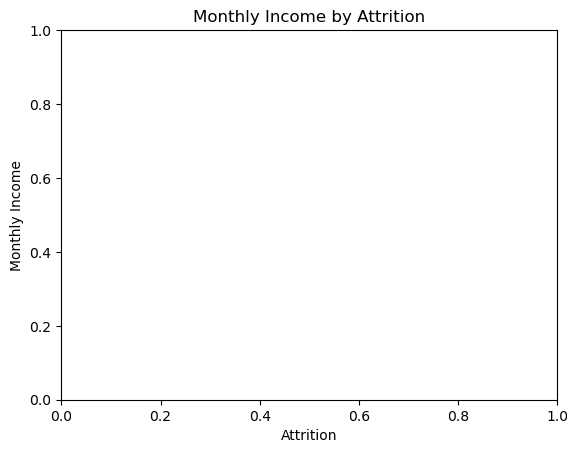

In [18]:
plt.title("Monthly Income by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

In [19]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Visualization 3: Job Satisfaction vs Attrition

In [20]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [21]:
attrition_job_satisfaction = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

<Axes: xlabel='JobSatisfaction'>

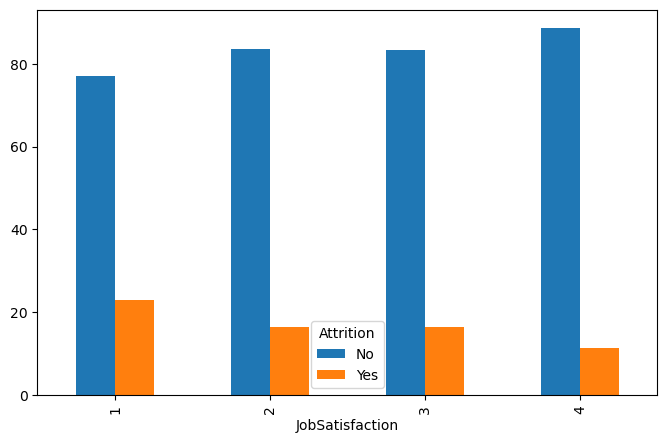

In [22]:
attrition_job_satisfaction.plot(
    kind="bar",
    figsize=(8, 5)
)

/var/folders/37/z30nsxts57lc44x8cvjdrn880000gn/T/ipykernel_38163/4194095591.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Attrition")


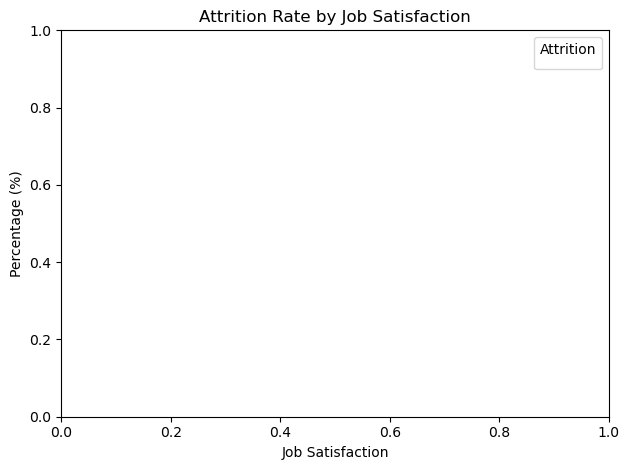

In [23]:
plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

Visualization 4: Attrition by Job Role

In [24]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [25]:
attrition_job_role = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

<Axes: xlabel='JobRole'>

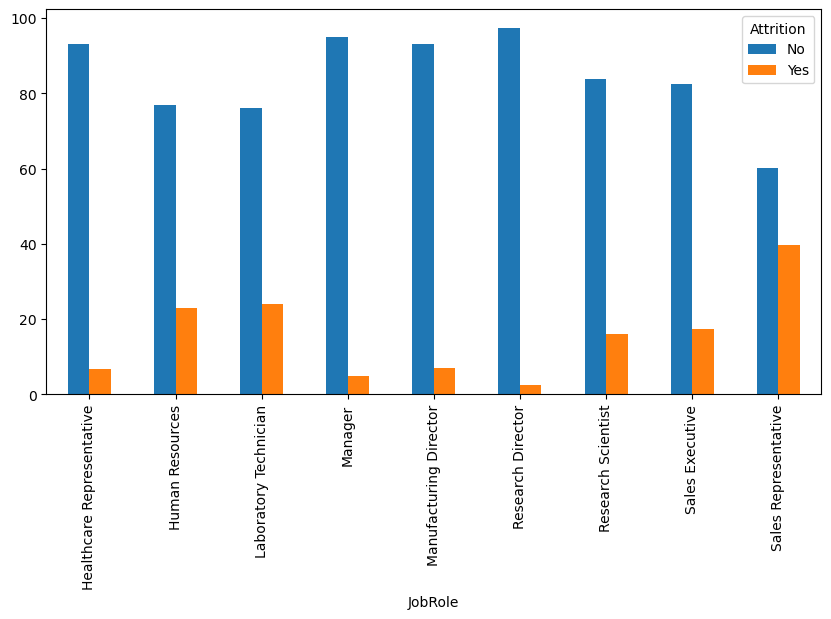

In [26]:
attrition_job_role.plot(
    kind="bar",
    figsize=(10, 5)
)

/var/folders/37/z30nsxts57lc44x8cvjdrn880000gn/T/ipykernel_38163/1143458556.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Attrition")


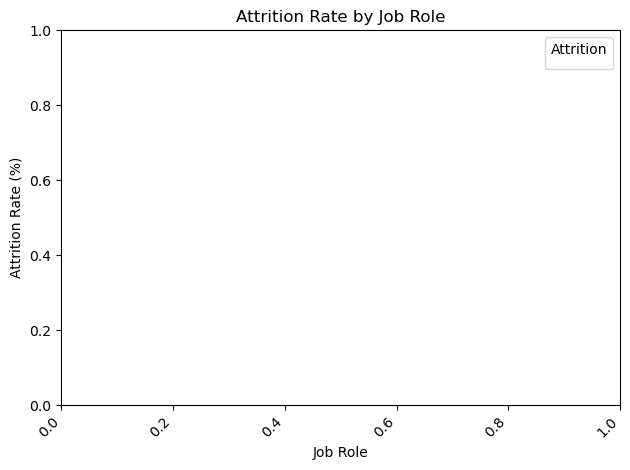

In [27]:
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

Visualization 5: Attrition by Age

In [28]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [29]:
age_attrition = pd.crosstab(
    df["Age"],
    df["Attrition"],
    normalize="index"
) * 100

<Axes: xlabel='Age'>

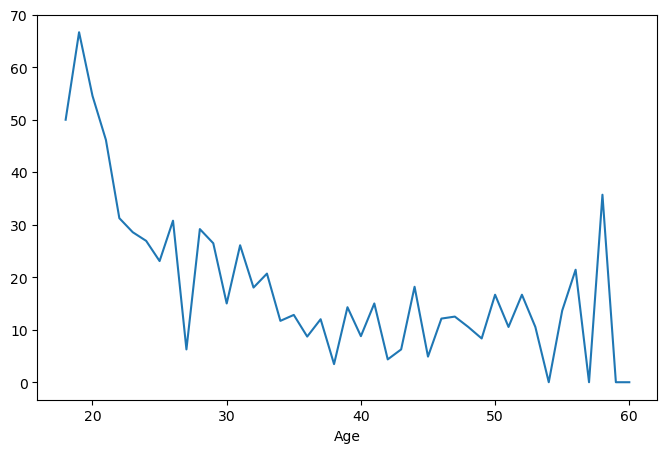

In [30]:
age_attrition["Yes"].plot(kind="line", figsize=(8, 5))

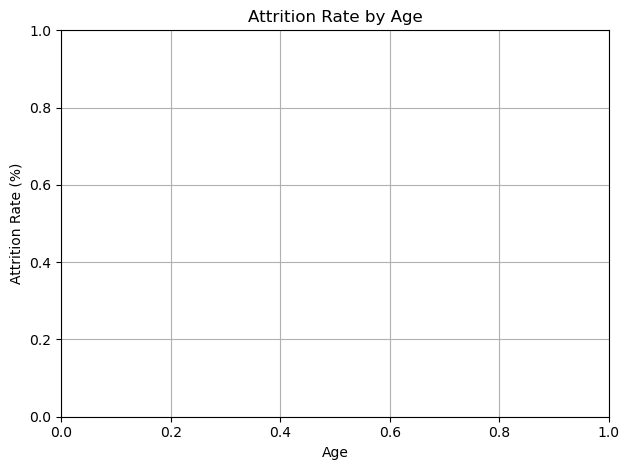

In [31]:
plt.title("Attrition Rate by Age")
plt.xlabel("Age")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

Visualization 6: Attrition by Job Involvement

In [32]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [33]:
job_involvement_attrition = pd.crosstab(
    df["JobInvolvement"],
    df["Attrition"],
    normalize="index"
) * 100

<Axes: xlabel='JobInvolvement'>

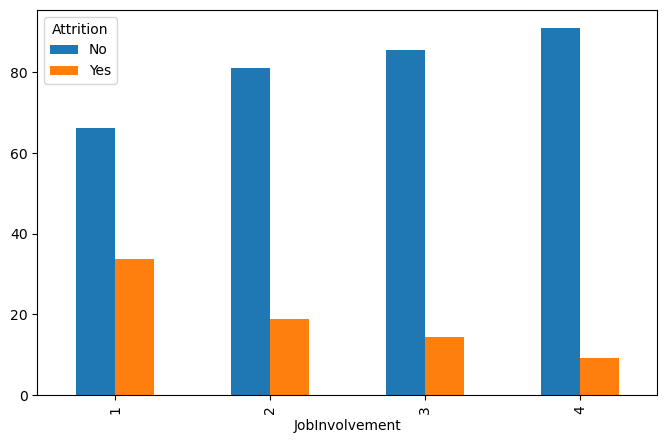

In [34]:
job_involvement_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

/var/folders/37/z30nsxts57lc44x8cvjdrn880000gn/T/ipykernel_38163/3063551934.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Attrition")


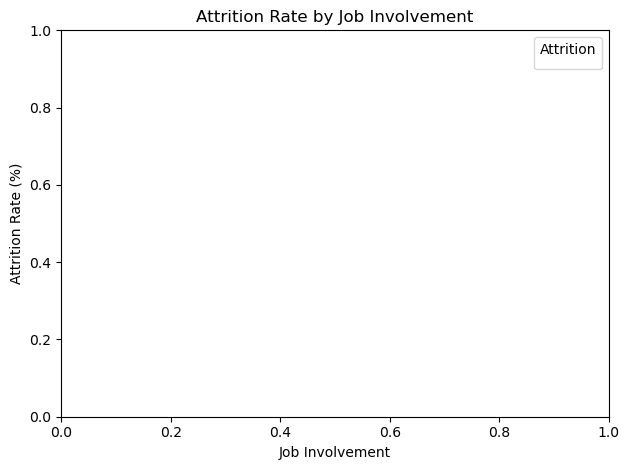

In [35]:
plt.title("Attrition Rate by Job Involvement")
plt.xlabel("Job Involvement")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

============================================================
OBSERVATIONS
============================================================

In [36]:
print("\n=== Key Observations ===")


=== Key Observations ===


In [37]:
print("1. Employees working overtime have a higher attrition rate than employees who do not work overtime.")

1. Employees working overtime have a higher attrition rate than employees who do not work overtime.


In [38]:
print("2. Employees who left the company generally have lower monthly income than employees who stayed.")

2. Employees who left the company generally have lower monthly income than employees who stayed.


In [39]:
print("3. Employees with lower job satisfaction show higher attrition compared with employees having higher job satisfaction.")

3. Employees with lower job satisfaction show higher attrition compared with employees having higher job satisfaction.


In [40]:
print("4. Attrition varies considerably across different job roles, with Sales Representatives showing relatively high attrition.")

4. Attrition varies considerably across different job roles, with Sales Representatives showing relatively high attrition.


In [41]:
print("5. Younger employees show higher attrition rates compared with many older age groups.")

5. Younger employees show higher attrition rates compared with many older age groups.


In [42]:
print("6. Employees with lower job involvement have higher attrition compared with employees having higher job involvement.")

6. Employees with lower job involvement have higher attrition compared with employees having higher job involvement.


============================================================
MACHINE LEARNING - EMPLOYEE ATTRITION PREDICTION
============================================================

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [44]:
print("\n=== MACHINE LEARNING ===")


=== MACHINE LEARNING ===


In [45]:
# Create a copy of the dataset
ml_df = df.copy()

In [46]:
# Encode target variable
ml_df["Attrition"] = ml_df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [47]:
# Convert categorical variables into numerical dummy variables
ml_df = pd.get_dummies(ml_df, drop_first=True)

In [48]:
# Separate features and target
columns_to_drop = [
    "Attrition",
    "EmployeeNumber",
    "EmployeeCount",
    "StandardHours"
]

In [49]:
X = ml_df.drop(columns=columns_to_drop)
y = ml_df["Attrition"]

In [50]:
# Split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
print("\nOriginal training distribution:")
print(y_train.value_counts())


Original training distribution:
Attrition
0    986
1    190
Name: count, dtype: int64


============================================================
SMOTE - BALANCE TRAINING DATA ONLY
============================================================

In [52]:
smote = SMOTE(random_state=42)

In [53]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [54]:
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


============================================================
LOGISTIC REGRESSION
============================================================

In [55]:
log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [56]:
log_model.fit(X_train_smote, y_train_smote)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000, random_state=42)

In [57]:
y_pred_log = log_model.predict(X_test)

In [58]:
print("\n=== Logistic Regression + SMOTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== Logistic Regression + SMOTE ===
Accuracy: 0.8027210884353742
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       247
           1       0.40      0.49      0.44        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.66       294
weighted avg       0.82      0.80      0.81       294



============================================================
RANDOM FOREST
============================================================

In [59]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [60]:
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [61]:
y_pred_rf = rf_model.predict(X_test)

In [62]:
print("\n=== Random Forest + SMOTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


=== Random Forest + SMOTE ===
Accuracy: 0.8163265306122449
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       247
           1       0.38      0.23      0.29        47

    accuracy                           0.82       294
   macro avg       0.62      0.58      0.59       294
weighted avg       0.79      0.82      0.80       294



============================================================
CONFUSION MATRIX - LOGISTIC REGRESSION + SMOTE
============================================================

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [64]:
cm_smote = confusion_matrix(y_test, y_pred_log)

In [65]:
print("\n=== Confusion Matrix - Logistic Regression + SMOTE ===")
print(cm_smote)


=== Confusion Matrix - Logistic Regression + SMOTE ===
[[213  34]
 [ 24  23]]


In [66]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["No Attrition", "Attrition"]
)

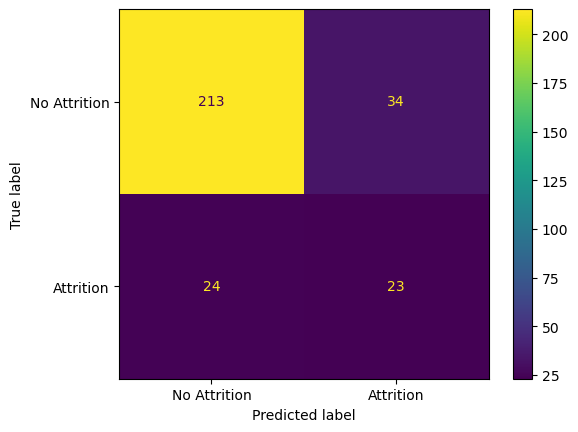

In [67]:
disp.plot()

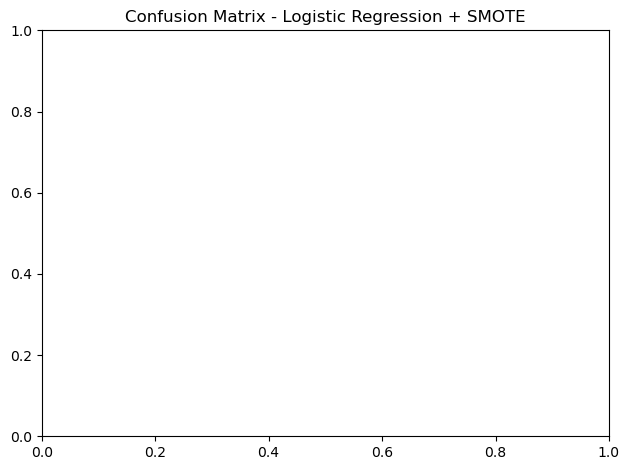

In [68]:
plt.title("Confusion Matrix - Logistic Regression + SMOTE")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_logistic.png", dpi=300, bbox_inches="tight")
plt.show()

============================================================
CONFUSION MATRIX - RANDOM FOREST + SMOTE
============================================================

In [69]:
cm_rf_smote = confusion_matrix(y_test, y_pred_rf)

In [70]:
print("\n=== Confusion Matrix - Random Forest + SMOTE ===")
print(cm_rf_smote)


=== Confusion Matrix - Random Forest + SMOTE ===
[[229  18]
 [ 36  11]]


In [71]:
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_smote,
    display_labels=["No Attrition", "Attrition"]
)

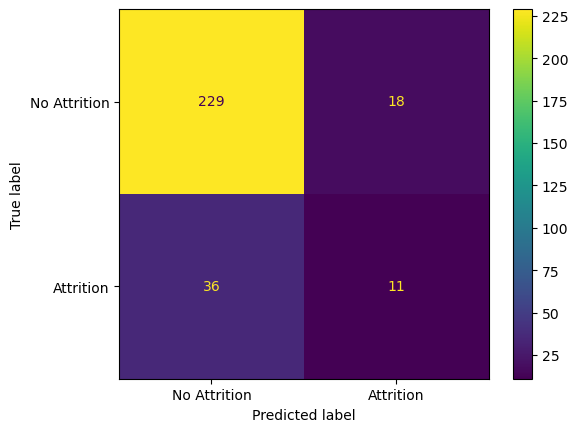

In [72]:
disp_rf.plot()

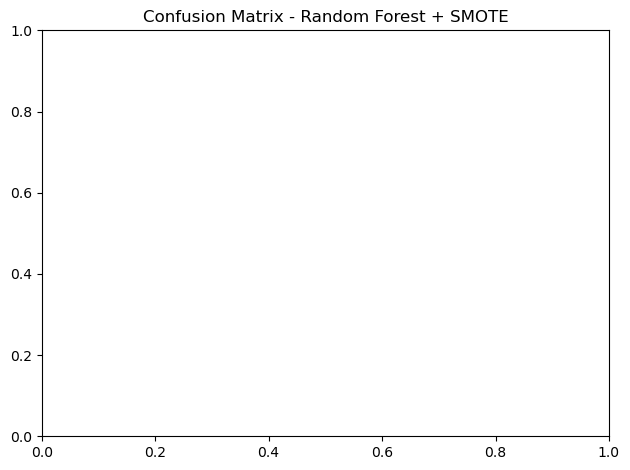

In [73]:
plt.title("Confusion Matrix - Random Forest + SMOTE")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

============================================================
ROC-AUC COMPARISON
============================================================

In [74]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [75]:
# Logistic Regression probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [76]:
# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [77]:
# Calculate ROC-AUC
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

In [78]:
print("\n=== ROC-AUC Comparison ===")
print("Logistic Regression + SMOTE:", round(auc_log, 4))
print("Random Forest + SMOTE:", round(auc_rf, 4))


=== ROC-AUC Comparison ===
Logistic Regression + SMOTE: 0.7113
Random Forest + SMOTE: 0.7458


In [79]:
# ROC curves
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

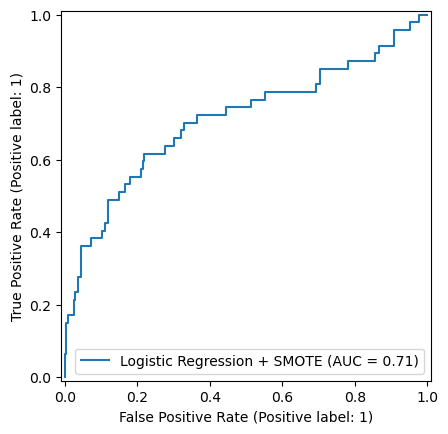

In [80]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name="Logistic Regression + SMOTE"
)

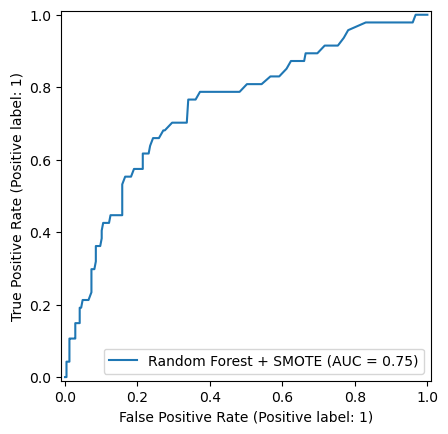

In [81]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest + SMOTE"
)

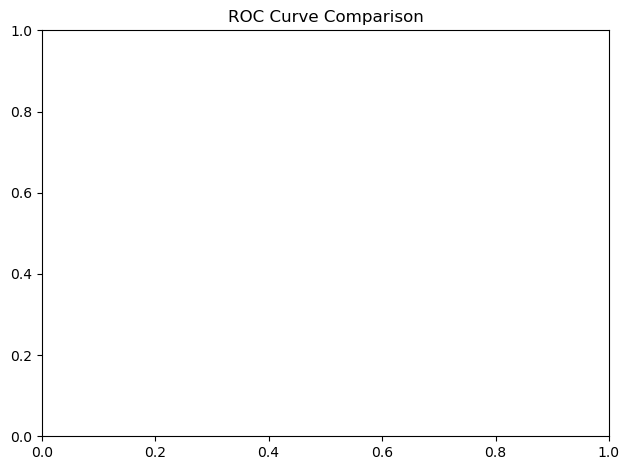

In [82]:
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig("plots/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

============================================================
LOGISTIC REGRESSION - FEATURE COEFFICIENTS
============================================================

In [83]:
feature_coefficients = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values()

In [84]:
print("\n=== Top 10 Factors Associated With Higher Attrition Prediction ===")
print(feature_coefficients.tail(10).sort_values(ascending=False))


=== Top 10 Factors Associated With Higher Attrition Prediction ===
PerformanceRating                0.751577
OverTime_Yes                     0.484965
NumCompaniesWorked               0.113967
JobRole_Laboratory Technician    0.069956
DistanceFromHome                 0.053674
PercentSalaryHike                0.049279
YearsSinceLastPromotion          0.034888
YearsAtCompany                   0.031282
Age                              0.026847
TrainingTimesLastYear            0.025296
dtype: float64


In [85]:
print("\n=== Top 10 Factors Associated With Lower Attrition Prediction ===")
print(feature_coefficients.head(10))


=== Top 10 Factors Associated With Lower Attrition Prediction ===
StockOptionLevel                    -1.130077
MaritalStatus_Married               -0.915844
Department_Research & Development   -0.854495
EducationField_Medical              -0.763135
EducationField_Life Sciences        -0.681777
JobRole_Research Scientist          -0.627848
BusinessTravel_Travel_Rarely        -0.486366
JobInvolvement                      -0.400251
JobSatisfaction                     -0.392964
EnvironmentSatisfaction             -0.378315
dtype: float64


In [86]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]

============================================================
EMPLOYEE ATTRITION RISK LEVEL
============================================================

In [87]:
# Create a risk table from the test data
risk_df = df.loc[X_test.index].copy()

In [88]:
# Add predicted attrition probability
risk_df["Attrition_Probability"] = y_prob_log

In [89]:
# Assign risk level
def assign_risk(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

In [90]:
risk_df["Risk_Level"] = risk_df["Attrition_Probability"].apply(assign_risk)

In [91]:
# Sort employees from highest to lowest risk
risk_df = risk_df.sort_values(
    by="Attrition_Probability",
    ascending=False
)

In [92]:
# Select top 20 employees
top_20_risk = risk_df[
    ["EmployeeNumber", "Attrition_Probability", "Risk_Level"]
].head(20)

In [93]:
print("\n=== TOP 20 EMPLOYEE ATTRITION RISK ===")
print(top_20_risk.to_string(index=False))


=== TOP 20 EMPLOYEE ATTRITION RISK ===
 EmployeeNumber  Attrition_Probability Risk_Level
            248               0.987401       High
           1157               0.922059       High
            478               0.919443       High
            467               0.899594       High
            994               0.878230       High
           1210               0.876074       High
           1273               0.853545       High
           1082               0.842202       High
           2018               0.826624       High
            720               0.818683       High
           1554               0.782800       High
           1961               0.781102       High
            744               0.776585       High
           1461               0.775150       High
            991               0.774548       High
           1318               0.764683       High
            496               0.757515       High
             47               0.749695       High
          

============================================================
OBSERVATIONS VS POSSIBLE INSIGHTS
============================================================

In [94]:
print("\n=== OBSERVATIONS VS POSSIBLE INSIGHTS ===")


=== OBSERVATIONS VS POSSIBLE INSIGHTS ===


In [95]:
print("\n1. Observation:")
print("Employees working overtime show a higher attrition rate than employees who do not work overtime.")
print("Possible Insight:")
print("Overtime is associated with higher employee attrition risk, suggesting that workload patterns may be relevant for retention monitoring.")


1. Observation:
Employees working overtime show a higher attrition rate than employees who do not work overtime.
Possible Insight:
Overtime is associated with higher employee attrition risk, suggesting that workload patterns may be relevant for retention monitoring.


In [96]:
print("\n2. Observation:")
print("Employees who left the company generally have lower monthly income than employees who stayed.")
print("Possible Insight:")
print("Monthly income shows an association with attrition patterns, indicating that compensation may be relevant when examining employee retention.")


2. Observation:
Employees who left the company generally have lower monthly income than employees who stayed.
Possible Insight:
Monthly income shows an association with attrition patterns, indicating that compensation may be relevant when examining employee retention.


In [97]:
print("\n3. Observation:")
print("Employees with lower job satisfaction show higher attrition compared with employees having higher job satisfaction.")
print("Possible Insight:")
print("Job satisfaction is associated with differences in attrition patterns and may be useful when identifying employees requiring retention attention.")


3. Observation:
Employees with lower job satisfaction show higher attrition compared with employees having higher job satisfaction.
Possible Insight:
Job satisfaction is associated with differences in attrition patterns and may be useful when identifying employees requiring retention attention.


In [98]:
print("\n4. Observation:")
print("Attrition varies across different job roles, with some roles showing higher attrition than others.")
print("Possible Insight:")
print("Job role is associated with different levels of attrition risk, suggesting that retention strategies may need to consider role-specific patterns.")


4. Observation:
Attrition varies across different job roles, with some roles showing higher attrition than others.
Possible Insight:
Job role is associated with different levels of attrition risk, suggesting that retention strategies may need to consider role-specific patterns.


In [99]:
print("\n5. Observation:")
print("Younger employees show higher attrition rates compared with many older age groups.")
print("Possible Insight:")
print("Age groups show different attrition patterns, with younger employees appearing more frequently in higher-attrition groups.")


5. Observation:
Younger employees show higher attrition rates compared with many older age groups.
Possible Insight:
Age groups show different attrition patterns, with younger employees appearing more frequently in higher-attrition groups.


In [100]:
print("\n6. Observation:")
print("Employees with lower job involvement have higher attrition compared with employees having higher job involvement.")
print("Possible Insight:")
print("Job involvement is associated with attrition patterns and may be relevant when assessing employee retention risk.")


6. Observation:
Employees with lower job involvement have higher attrition compared with employees having higher job involvement.
Possible Insight:
Job involvement is associated with attrition patterns and may be relevant when assessing employee retention risk.


============================================================
BUSINESS ACTIONS
============================================================

In [101]:
print("\n=== 5 BUSINESS ACTIONS ===")


=== 5 BUSINESS ACTIONS ===


In [102]:
print("""
1. Overtime Management:
Monitor employees working overtime and review workload distribution
to reduce excessive workload and potential attrition risk.

2. Employee Satisfaction Programs:
Conduct regular employee satisfaction surveys and address concerns
related to job satisfaction and work environment.

3. Compensation and Career Growth:
Review compensation, promotion opportunities, and career development
for employees showing higher attrition risk.

4. Role-Specific Retention:
Identify job roles with higher attrition patterns and develop
role-specific retention and engagement strategies.

5. Early Risk Monitoring:
Use the ML-based attrition probability and Risk_Level classification
to identify employees requiring retention attention and prioritize
appropriate HR interventions.
""")


1. Overtime Management:
Monitor employees working overtime and review workload distribution
to reduce excessive workload and potential attrition risk.

2. Employee Satisfaction Programs:
Conduct regular employee satisfaction surveys and address concerns
related to job satisfaction and work environment.

3. Compensation and Career Growth:
Review compensation, promotion opportunities, and career development
for employees showing higher attrition risk.

4. Role-Specific Retention:
Identify job roles with higher attrition patterns and develop
role-specific retention and engagement strategies.

5. Early Risk Monitoring:
Use the ML-based attrition probability and Risk_Level classification
to identify employees requiring retention attention and prioritize
appropriate HR interventions.

